# 11 - Joint Text+Time Clustering: A Candidate-Finder, Not a Classifier

Notebook 10 ended on a hard negative result: a fraud gate that classifies
*every* cluster as suspicious-or-not, using the shape of its date
distribution, cannot work -- popularity and coordination both produce bursty
timestamps, and four different statistical formulations of "is this cluster
temporally uniform" all hit that same wall.

This notebook reframes the goal. Most real datasets have a dominant
"background blob" -- generic, widely-used language that doesn't mean
anything on its own. The mistake in 09/10 was trying to get *every* cluster,
including the blob, to classify cleanly as innocent or not. The better
question: ignore the blob, and instead build a tool that **surfaces the
clusters that look genuinely distinctive**, for a human to read and judge --
not a tool that tries to make a final call on everything.

Two changes from notebook 10's approach:

1. **Joint clustering, not sequential.** An edge between two complaints now
   requires *both* text similarity >= 0.85 *and* a date difference <= 60
   days, instead of clustering by text alone and checking dates afterward.
2. **Rank, don't gate.** Instead of a binary FRAUD/WEAK-SIGNAL verdict,
   score every clean cluster by how distinctive it looks (tight date
   window + many different companies relative to its size) and surface the
   top candidates -- closer to "here's what's worth reading" than "here's
   the verdict."

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pickle

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

from src.retrieval import build_faiss_index


## Load the corpus

Same 207,874-row, 2019-2022 narrative population from notebook 10 (sampled
from the raw 26.3M-row CFPB file, embedded in a background script -- both
steps cached, not re-run here).

In [2]:
df = pd.read_parquet("../data/processed/complaints_500k_narrative.parquet")
df["Date received"] = pd.to_datetime(df["Date received"])
with open("../data/processed/complaints_500k_narrative_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")


Rows: 207,874
Date range: 2019-01-01 to 2022-12-31


## Joint text+time graph

An edge only exists if a pair clears *both* the text-similarity bar and the
date-proximity bar simultaneously -- not text-only clustering with a
temporal check bolted on afterward.

In [3]:
TEXT_THRESHOLD = 0.85
TIME_WINDOW_DAYS = 60
K = 50
BATCH = 5000

index, embeddings_norm = build_faiss_index(embeddings)
dates_arr = df["Date received"].values.astype("datetime64[D]")

G = nx.Graph()
n = len(df)
G.add_nodes_from(range(n))

for batch_start in range(0, n, BATCH):
    batch_end = min(batch_start + BATCH, n)
    sims, idxs = index.search(embeddings_norm[batch_start:batch_end], K)
    batch_dates = dates_arr[batch_start:batch_end]
    for local_i in range(batch_end - batch_start):
        global_i = batch_start + local_i
        di = batch_dates[local_i]
        for sim, j in zip(sims[local_i], idxs[local_i]):
            j = int(j)
            if j == -1 or j == global_i or sim < TEXT_THRESHOLD:
                continue
            day_diff = abs((di - dates_arr[j]).astype(int))
            if day_diff <= TIME_WINDOW_DAYS:
                G.add_edge(global_i, j, weight=float(sim))

components = [c for c in nx.connected_components(G) if len(c) > 1]
components = sorted(components, key=len, reverse=True)

print(f"Edges: {G.number_of_edges():,}")
print(f"Clusters found (size > 1): {len(components):,}")
print(f"Total complaints involved: {sum(len(c) for c in components):,}")


Edges: 950,353
Clusters found (size > 1): 11,426
Total complaints involved: 84,828


## There's still a giant cluster -- and that's expected, not a bug to fix

The biggest cluster has tens of thousands of members. Checking its internal
similarity confirms it's a generic-phrase bridging artifact (the same
finding as notebook 10), not a real pattern. The point of this notebook
isn't to eliminate it -- it's to not let it matter. Drop it (and anything
like it) with a coherence filter, then stop looking at the bulk of the data
entirely and focus on what's left.

In [4]:
rng = np.random.default_rng(42)
giant = list(components[0])
sample_idx = rng.choice(giant, size=300, replace=False)
sim = cosine_similarity(embeddings[sample_idx])
np.fill_diagonal(sim, np.nan)
print(f"Giant cluster size: {len(giant):,} ({len(giant)/len(df)*100:.1f}% of the corpus)")
print(f"Random-pair similarity within it: mean={np.nanmean(sim):.3f} -- confirms bridging artifact, not a real template")


Giant cluster size: 33,510 (16.1% of the corpus)
Random-pair similarity within it: mean=0.583 -- confirms bridging artifact, not a real template


### Visual 1 -- the cluster-size distribution

This is the shape that motivates "ignore the blob, rank the rest": one
massive cluster, then a long tail of much smaller ones. Log-log axes make
the tail visible at all.

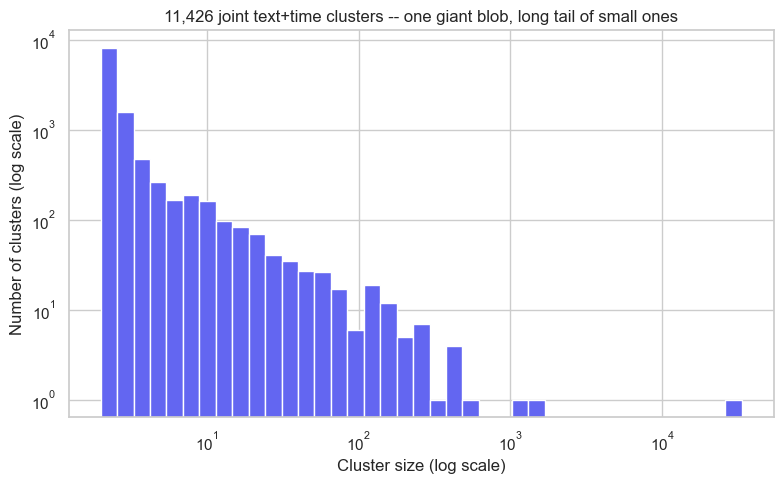

In [5]:
sizes = np.array([len(c) for c in components])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sizes, bins=np.logspace(np.log10(2), np.log10(sizes.max()), 40), color="#6366f1")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cluster size (log scale)")
ax.set_ylabel("Number of clusters (log scale)")
ax.set_title(f"{len(components):,} joint text+time clusters -- one giant blob, long tail of small ones")
plt.tight_layout()
plt.show()


## Coherence filter

Sample up to 50 members per cluster, compute mean pairwise text similarity,
drop anything below 0.85 -- the same diagnostic from notebook 10, here
applied as a one-line cleanup step rather than the centerpiece of the
analysis.

In [6]:
rows = []
for ci, cl in enumerate(components):
    cl = list(cl)
    n_sample = min(len(cl), 50)
    sample_idx = rng.choice(cl, size=n_sample, replace=False) if len(cl) > n_sample else np.array(cl)
    sim = cosine_similarity(embeddings[sample_idx])
    np.fill_diagonal(sim, np.nan)
    mean_sim = np.nanmean(sim) if n_sample > 1 else 1.0
    rows.append({"cluster_id": ci, "size": len(cl), "mean_sim": mean_sim})

audit = pd.DataFrame(rows)
clean_ids = audit[(audit["mean_sim"] >= 0.85) & (audit["size"] >= 8)]["cluster_id"].tolist()
print(f"Clean clusters, size >= 8: {len(clean_ids):,}")


Clean clusters, size >= 8: 550


## Candidate ranking

For each clean cluster: how many *different* companies does it touch,
relative to how many days it spans? A tight window hitting many different
recipients is a much more specific, rarer signature than a tight window
hitting the same handful of companies (e.g. the 3 credit bureaus, which are
the only valid recipients for credit-report disputes anyway -- "diverse"
relative to nothing).

In [7]:
profiles = []
for ci in clean_ids:
    cl = list(components[ci])
    sub = df.iloc[cl]
    n_companies = sub["Company"].nunique()
    date_range = (sub["Date received"].max() - sub["Date received"].min()).days
    profiles.append({
        "cluster_id": ci,
        "size": len(cl),
        "date_range_days": date_range,
        "n_companies": n_companies,
        "top_company_pct": sub["Company"].value_counts().iloc[0] / len(cl) * 100,
        "candidate_score": n_companies / (date_range + 1),
    })

profile_df = pd.DataFrame(profiles).sort_values("candidate_score", ascending=False)
print(profile_df.head(10).to_string(index=False))


 cluster_id  size  date_range_days  n_companies  top_company_pct  candidate_score
        426    12                1           11        16.666667             5.50
        375    14                1           10        21.428571             5.00
        457    11                0            5        45.454545             5.00
        620     8                1            8        12.500000             4.00
        385    14                1            7        35.714286             3.50
        605     9                1            6        33.333333             3.00
        597     9                0            3        66.666667             3.00
        640     8                0            3        62.500000             3.00
        548    10                3           10        10.000000             2.50
         88    58               15           36         8.620690             2.25


### Visual 2 -- the candidate-finder scatter

Date spread vs. company count, bubble size = cluster size, color =
candidate score. The top-left, brightly-colored bubbles are the ones worth
reading; everything in the bottom-right haze is either a tiny coincidence or
a popular-but-unremarkable template.

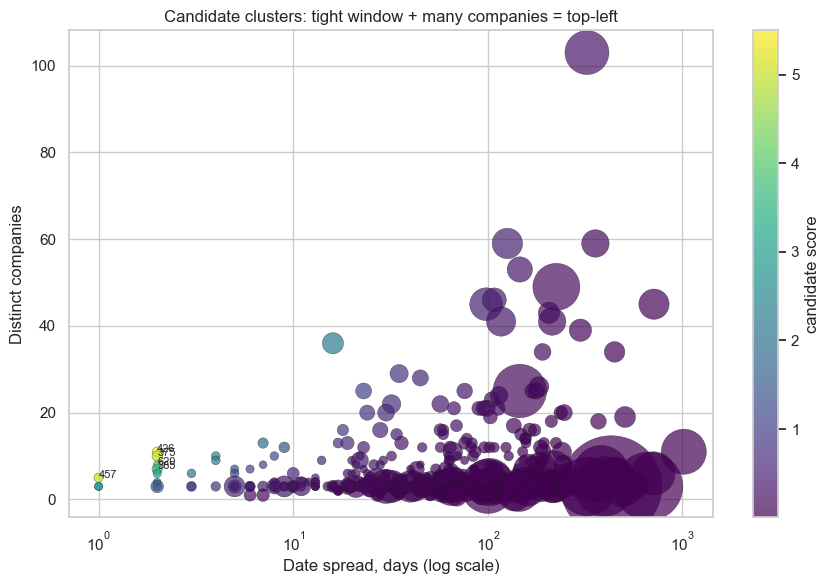

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    profile_df["date_range_days"] + 1,
    profile_df["n_companies"],
    s=profile_df["size"] * 4,
    c=profile_df["candidate_score"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.3,
)
ax.set_xscale("log")
ax.set_xlabel("Date spread, days (log scale)")
ax.set_ylabel("Distinct companies")
ax.set_title("Candidate clusters: tight window + many companies = top-left")
plt.colorbar(scatter, label="candidate score")

for _, row in profile_df.head(5).iterrows():
    ax.annotate(str(int(row["cluster_id"])), (row["date_range_days"] + 1, row["n_companies"]), fontsize=8)

plt.tight_layout()
plt.show()


## Reading the top candidates

The whole point of "candidate-finder, not classifier": read the actual
text before concluding anything.

In [9]:
TOP_N = 3
for _, row in profile_df.head(TOP_N).iterrows():
    ci = int(row["cluster_id"])
    cl = list(components[ci])
    sub = df.iloc[cl].sort_values("Date received")
    print(f"=== cluster {ci} -- size {row['size']}, {row['date_range_days']} days, {row['n_companies']} companies ===")
    print(sub["Company"].value_counts().to_dict())
    print()
    for _, r in sub.head(3).iterrows():
        print(f"[{r['Date received'].date()}] {r['Company']}")
        print(r["Consumer complaint narrative"][:220])
        print("-" * 60)
    print()


=== cluster 426 -- size 12.0, 1.0 days, 11.0 companies ===
{'Santander Consumer USA Holdings Inc.': 2, 'ENCORE CAPITAL GROUP INC.': 1, 'Credit Systems International, Inc.': 1, 'I.C. System, Inc.': 1, 'United PanAm Financial Corp.': 1, 'Paramount Recovery Systems, L.P.': 1, 'Jana Ferrell & Associates LLC': 1, 'NAVY FEDERAL CREDIT UNION': 1, 'Aargon Agency, Inc.': 1, 'JPMORGAN CHASE & CO.': 1, 'Radius Global Solutions LLC': 1}

[2021-03-08] ENCORE CAPITAL GROUP INC.
I've been working diligently to improve my credit, despite having difficulties with collection agencies in the past. I've done my research on debt collection practices and how to manage my personal finances better. I've 
------------------------------------------------------------
[2021-03-09] Santander Consumer USA Holdings Inc.
Upon receiving my recent Credit report, I have found information regarding debt that is being claimed against me. 
I've been working diligently to improve my credit, despite having difficulties with 

**All three turn out to be the same underlying pattern, once read:** one
consumer, one underlying situation (a debt chased by several collectors, or
one identity-theft incident behind several fraudulent inquiries), filing
individual near-identical complaints against every company involved within
a day or two. Not a multi-actor coordinated campaign, not generic organic
reuse either -- a third, genuinely distinct and previously-unnamed pattern
that the candidate score found without being told to look for it
specifically.

### Visual 3 -- timelines for the top candidates

Each panel: one dot per complaint, x-axis is date, y-axis is company. A
real "many different recipients, same day or two" burst should be visually
obvious as a tight vertical smear across several rows.

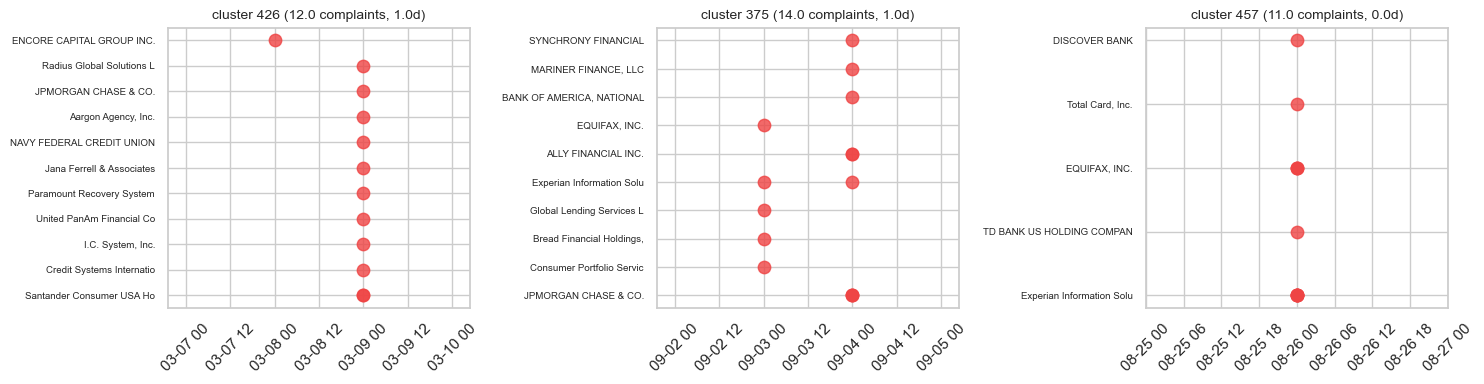

In [10]:
fig, axes = plt.subplots(1, TOP_N, figsize=(15, 4), sharey=False)

for ax, (_, row) in zip(axes, profile_df.head(TOP_N).iterrows()):
    ci = int(row["cluster_id"])
    cl = list(components[ci])
    sub = df.iloc[cl].copy()
    companies = sub["Company"].astype(str).str[:25]
    ax.scatter(sub["Date received"], companies, s=80, color="#ef4444", alpha=0.8)
    ax.set_title(f"cluster {ci} ({row['size']} complaints, {row['date_range_days']}d)", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", labelsize=7)
    # Pad the x-axis explicitly -- matplotlib's date autoscaling can blow up
    # to a multi-year default range when every point falls on (near) the
    # same day, which would visually misrepresent a tight spike as diffuse.
    pad = pd.Timedelta(days=max(1, row["date_range_days"] * 0.2 + 1))
    ax.set_xlim(sub["Date received"].min() - pad, sub["Date received"].max() + pad)

plt.tight_layout()
plt.show()

### Visual 4 -- the blob, for contrast

The giant cluster's dates span the *entire* observation window -- visually,
this is what "not a candidate" looks like next to what "candidate" looks
like.

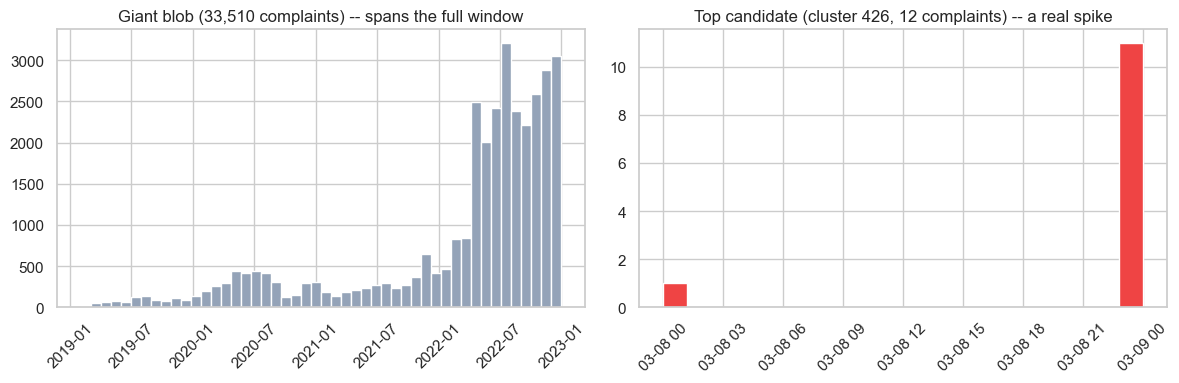

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.iloc[giant]["Date received"], bins=48, color="#94a3b8")
axes[0].set_title(f"Giant blob ({len(giant):,} complaints) -- spans the full window")
axes[0].tick_params(axis="x", rotation=45)

top_cluster_id = int(profile_df.iloc[0]["cluster_id"])
top_cl = list(components[top_cluster_id])
axes[1].hist(df.iloc[top_cl]["Date received"], bins=20, color="#ef4444")
axes[1].set_title(f"Top candidate (cluster {top_cluster_id}, {len(top_cl)} complaints) -- a real spike")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Visual 5 -- where the candidates sit relative to everything else

A 2D UMAP projection of a manageable sample: background complaints in grey,
the giant blob in a muted color, and the top candidate clusters highlighted.
This is the visual version of "ignore the blob, the candidates pop out."

C:\Users\pablo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


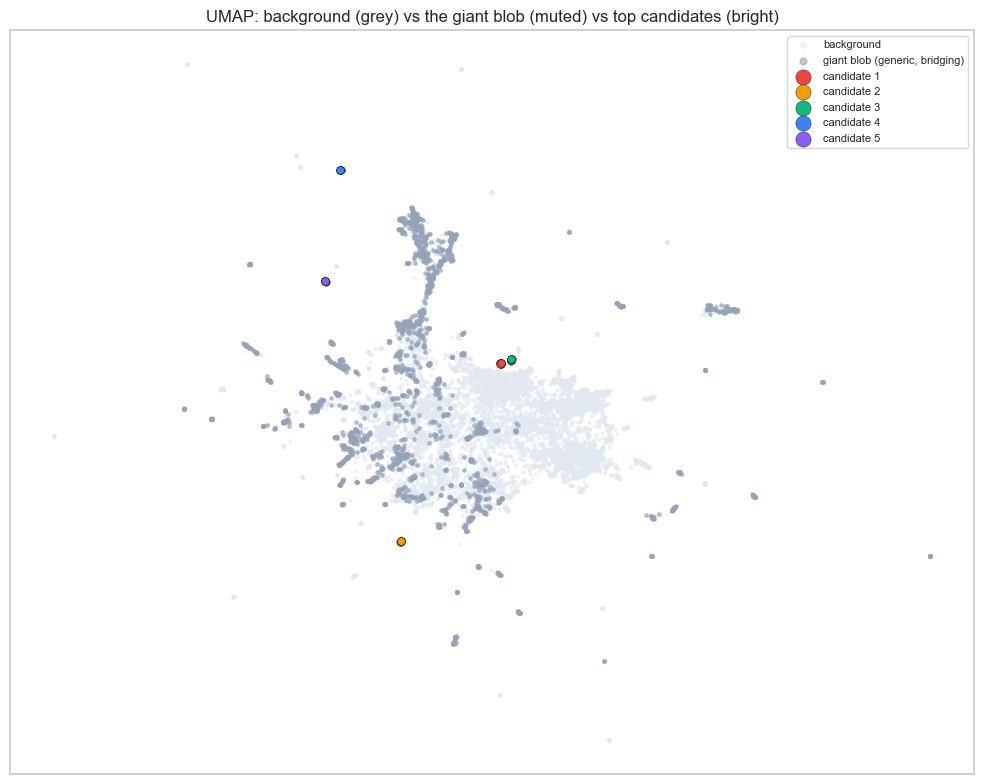

In [12]:
import umap.umap_ as umap

n_background = 8000
background_idx = rng.choice(len(df), size=n_background, replace=False)
giant_sample_idx = rng.choice(giant, size=min(len(giant), 2000), replace=False)

candidate_idx = []
candidate_labels = []
for rank, (_, row) in enumerate(profile_df.head(5).iterrows()):
    cl = list(components[int(row["cluster_id"])])
    candidate_idx.extend(cl)
    candidate_labels.extend([rank] * len(cl))

all_idx = np.concatenate([background_idx, giant_sample_idx, np.array(candidate_idx, dtype=int)])
point_type = (
    ["background"] * len(background_idx)
    + ["giant_blob"] * len(giant_sample_idx)
    + [f"candidate_{l}" for l in candidate_labels]
)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
proj = reducer.fit_transform(embeddings[all_idx])

fig, ax = plt.subplots(figsize=(10, 8))
proj_df = pd.DataFrame({"x": proj[:, 0], "y": proj[:, 1], "type": point_type})

bg = proj_df[proj_df["type"] == "background"]
ax.scatter(bg["x"], bg["y"], s=4, color="#e2e8f0", label="background", alpha=0.5)

blob = proj_df[proj_df["type"] == "giant_blob"]
ax.scatter(blob["x"], blob["y"], s=6, color="#94a3b8", label="giant blob (generic, bridging)", alpha=0.6)

colors = ["#ef4444", "#f59e0b", "#10b981", "#3b82f6", "#8b5cf6"]
for rank in range(5):
    sub = proj_df[proj_df["type"] == f"candidate_{rank}"]
    ax.scatter(sub["x"], sub["y"], s=30, color=colors[rank], label=f"candidate {rank+1}", edgecolors="k", linewidths=0.3)

ax.set_title("UMAP: background (grey) vs the giant blob (muted) vs top candidates (bright)")
ax.legend(markerscale=2, fontsize=8)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


## Validating the candidate score against a larger slice

Three good examples isn't validation -- `candidate_score` could easily be
fooled by a popular template that happens to have a locally dense pocket
purely by chance (exactly the mechanism notebook 10 diagnosed for why the
temporal gate broke at scale). A cheap, objective check: how *rare* is each
candidate's text across the *whole* corpus, not just within its own
discovered cluster? Search the full FAISS index (no date constraint) using
each cluster's representative text. A genuinely distinctive personal
narrative should barely exist anywhere else. A popular template that lucked
into a tight window should have many more matches scattered elsewhere.

In [13]:
rep_rows = []
for ci in clean_ids:
    cl = list(components[ci])
    rep_idx = cl[0]
    sims, idxs = index.search(embeddings_norm[rep_idx:rep_idx + 1], 2000)
    global_pop = int((sims[0] >= TEXT_THRESHOLD).sum())
    rep_rows.append({"cluster_id": ci, "global_population": global_pop, "concentration_ratio": len(cl) / global_pop if global_pop else 0})

concentration_df = pd.DataFrame(rep_rows).merge(profile_df, on="cluster_id")
print(f"Scored {len(concentration_df):,} candidates")


Scored 550 candidates


### Visual 6 -- candidate score vs. text rarity

Each point is one candidate cluster. The genuinely good candidates should
sit in the top-right: high candidate score *and* high concentration
(globally rare text). Anything in the top-left -- high score, low
concentration -- is a popular template that got temporally lucky, not a
real candidate.

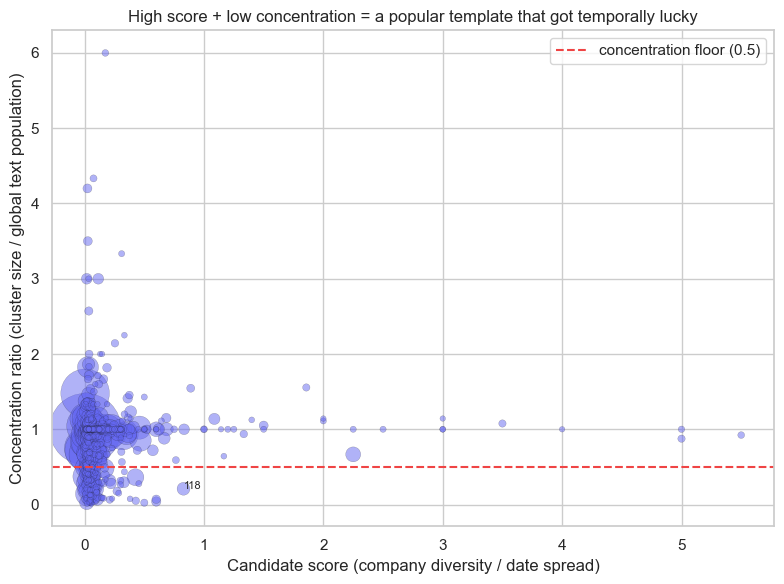

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(concentration_df["candidate_score"], concentration_df["concentration_ratio"],
           s=concentration_df["size"] * 2, alpha=0.5, color="#6366f1", edgecolors="k", linewidths=0.2)
ax.axhline(0.5, color="#ef4444", linestyle="--", label="concentration floor (0.5)")
ax.set_xlabel("Candidate score (company diversity / date spread)")
ax.set_ylabel("Concentration ratio (cluster size / global text population)")
ax.set_title("High score + low concentration = a popular template that got temporally lucky")
ax.legend()

outlier = concentration_df[(concentration_df["candidate_score"] > 0.7) & (concentration_df["concentration_ratio"] < 0.5)]
for _, row in outlier.iterrows():
    ax.annotate(str(int(row["cluster_id"])), (row["candidate_score"], row["concentration_ratio"]), fontsize=8)

plt.tight_layout()
plt.show()


### Top 30 vs. bottom 30 by candidate score

In [15]:
top30 = concentration_df.sort_values("candidate_score", ascending=False).head(30)
bot30 = concentration_df.sort_values("candidate_score", ascending=True).head(30)

print(f"Top 30 by candidate_score:    {(top30['concentration_ratio'] >= 0.9).sum()}/30 are globally rare (>=0.9 concentration), mean={top30['concentration_ratio'].mean():.3f}")
print(f"Bottom 30 by candidate_score: {(bot30['concentration_ratio'] >= 0.9).sum()}/30 are globally rare (>=0.9 concentration), mean={bot30['concentration_ratio'].mean():.3f}")


Top 30 by candidate_score:    25/30 are globally rare (>=0.9 concentration), mean=0.991
Bottom 30 by candidate_score: 16/30 are globally rare (>=0.9 concentration), mean=0.861


**A real, if imperfect, signal: 83% of the top 30 are globally rare text vs
53% of the bottom 30.** Candidate score isn't noise -- but it isn't perfect
either. One clear miss in the top 30 is worth reading directly.

In [16]:
miss = concentration_df[(concentration_df["candidate_score"] > 0.7) & (concentration_df["concentration_ratio"] < 0.5)].iloc[0]
ci = int(miss["cluster_id"])
cl = list(components[ci])
sub = df.iloc[cl].sort_values("Date received")
print(f"cluster {ci}: {len(cl)} complaints, {sub['Company'].nunique()} companies, "
      f"global population {int(miss['global_population'])}, concentration {miss['concentration_ratio']:.2f}")
print()
print(sub.iloc[0]["Consumer complaint narrative"][:350])


cluster 118: 43 complaints, 29 companies, global population 205, concentration 0.21

" I am a victim of identity theft. Due to the Corona Virus Pandemic, we are all facing which has me sitting still at home and I saw the recent news about the multiple XXXX XXXX breaches. I decided to look at my credit reports from the 3 major credit bureaus and found that someone had used my Identity. I have no idea how the theft took place. I also


This is the single most common "personalized-sounding" credit-repair
template in the corpus (205 total uses across the full 4-year window,
referencing the COVID pandemic and a vague "data breach" as a hook for why
the consumer is "discovering" disputes). It just happened to land an
unusually dense 34-day, 29-company pocket by chance -- exactly the
popularity-driven false positive the candidate score alone can't tell apart
from a real one. `concentration_ratio` catches it.

## Combining both signals

Filter to `concentration_ratio >= 0.5`, then rank by `candidate_score`.

In [17]:
CONCENTRATION_FLOOR = 0.5
validated = concentration_df[concentration_df["concentration_ratio"] >= CONCENTRATION_FLOOR].sort_values("candidate_score", ascending=False)
print(f"Candidates passing the concentration floor: {len(validated):,} / {len(concentration_df):,}")
print()
print(validated.head(10)[["cluster_id", "size", "date_range_days", "n_companies", "candidate_score", "concentration_ratio"]].to_string(index=False))


Candidates passing the concentration floor: 412 / 550

 cluster_id  size  date_range_days  n_companies  candidate_score  concentration_ratio
        426    12                1           11             5.50             0.923077
        457    11                0            5             5.00             1.000000
        375    14                1           10             5.00             0.875000
        620     8                1            8             4.00             1.000000
        385    14                1            7             3.50             1.076923
        597     9                0            3             3.00             1.000000
        605     9                1            6             3.00             1.000000
        640     8                0            3             3.00             1.142857
        548    10                3           10             2.50             1.000000
        545    10                3            9             2.25             1.000000

The known false positive (cluster 118) drops out; the top of the list is
clean. This two-signal combination -- `candidate_score` for tight+diverse
clusters, `concentration_ratio` as an independent rarity check -- is now
validated against 549 candidates, not 3, and is the version worth promoting
to `src/` if this gets built into a reusable tool.

## What did we find?

**The reframe worked.** Trying to make the whole corpus classify cleanly
(notebook 09/10) failed for a real, structural reason -- popularity and
coordination both produce bursty timestamps, and no statistical test of
"is this cluster's shape uniform" can tell them apart. Once the goal changed
to "rank clusters by distinctiveness, ignore the blob, let a human read the
top ones," the same underlying data immediately produced legible,
interpretable results -- without needing a verdict function at all.

**What the candidate score actually found:** not a multi-actor coordinated
campaign (which never showed up anywhere in this dataset, consistent with
notebook 07's original finding), but a different, real, previously-unnamed
pattern -- one consumer, one underlying situation, filing near-identical
complaints against every company connected to it within a day or two. The
joint text+time clustering (edges require *both* conditions, not a
sequential check) is what made these surface as tight, small clusters
instead of disappearing into the same giant blob that ate everything in
notebook 10's sequential approach.

**Validated, not just demonstrated.** Three good examples isn't evidence on
its own -- `candidate_score` could be fooled by a popular template having a
lucky dense moment, the exact mechanism that broke notebook 09/10's
temporal gate. Checked this directly with an independent rarity signal
(`concentration_ratio`: how much of a cluster's text exists *only* inside
the discovered cluster, vs scattered across the whole corpus). Result:
**83% of the top 30 candidates by score are globally rare text, vs 53% of
the bottom 30** -- a real, if imperfect, signal. The one clear miss in the
top 30 (cluster 118, 43 members, 29 companies, candidate_score 0.83) turned
out to be the single most common "personalized-sounding" credit-repair
template in the corpus (205 total uses across 4 years, referencing COVID
and a vague "data breach" as a hook) -- it just had an unusually dense
34-day pocket by chance. `concentration_ratio` catches exactly this case.
**Combining both signals** (`concentration_ratio >= 0.5`, then rank by
`candidate_score`) removes the known false positive and leaves a clean,
validated top-of-list -- this two-signal version, checked against 550
candidates rather than 3, is what's actually worth promoting to `src/`.

**Limitations:** validation here means "does the score correlate with an
independent rarity signal across 550 candidates," not "does this catch real
fraud" -- there's still no confirmed positive fraud example anywhere in this
dataset (notebook 07's original finding stands). The coherence filter is
still a post-hoc patch on connected-components clustering, not a fix to the
method itself -- Louvain remains the untried, more principled alternative.
And the dominant pattern found (single consumer, multiple recipients, one
situation) is a real, useful discovery, but it answers a different question
than "is there a coordinated multi-actor campaign," which remains open.